# Label-free Decoy-Competition FDR Gate — Demo

**Artifact:** *Label-free decoy-competition (knockoff⁺) FDR gate validated on CLUTRR crisp gold.*

A neuro-symbolic pipeline extracts kinship facts from short stories with an LLM, then must
decide **which extracted facts to admit into a symbolic (Prolog-style) layer — without gold
labels**. The idea: make each extracted **"real"** fact compete against a property-matched
**counterfactual decoy** (same ordered entity pair, a plausible-but-wrong relation, verified
*not* entailed by the gold) plus a random type-matched **swap** control. A label-free
confidence elicitation scores all three in isolated, provenance-blinded calls; the
**Barber–Candès knockoff⁺ rule** turns "decoy beats real" events into a **False-Discovery-Rate
certificate** — exactly the quantified hallucination control the project targets.

### What this demo shows (no API calls, runs in seconds)
The expensive part of the experiment was ~50k cached LLM scoring calls. Those scores are
**already baked into the released examples** (per-example rank-normalized real/decoy/swap
scores + the knockoff statistic `W` under two elicitations). This notebook **re-runs the
offline statistical core** (`fdr_stats.py`, embedded verbatim below) on those cached scores
to reproduce the headline result:

> **The gate's validity is elicitation-dependent.** Under single-token **logprob** confidence
> the LLM is overconfident in its *own spontaneous errors*, so counterfactual decoys are
> **anti-conservative** (tail win-rate ≪ 0.5). Under **K=5 self-consistency** confidence the
> decoys become **exchangeable** (win-rate ≈ 0.5) and the gate controls realized FDR.

`lp` = logprob elicitation, `pt` = portable (self-consistency) elicitation, throughout.

In [1]:
# --- Install dependencies (works on Colab and local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib are pre-installed on Colab — install locally at Colab's
# exact versions, but DO NOT touch them on Colab (would corrupt loaded C extensions).
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors method.py / fdr_stats.py) ---
import json, os, math, hashlib
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
# --- Data loader: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-2/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]            # cached per-real scores
ref = data["metadata_reference_full_run"]             # full 190-doc reported values

from collections import Counter
print(f"Loaded {len(examples)} reals from '{data['datasets'][0]['dataset']}'")
print("  labels   :", dict(Counter(e['output'] for e in examples)))
print("  fact_type:", dict(Counter(e['metadata_fact_type'] for e in examples)))
print("  documents:", len(set(e['metadata_doc_id'] for e in examples)))
print("\nFull-run headline verdict:", ref["headline_verdict"],
      "  (elicitation:", ref["headline_elicitation"] + ")")
# Peek at one cached example
ex = examples[0]
print("\nExample claim:", json.loads(ex['input'])['claim'], "->", ex['output'])
print("  logprob ranks   real/decoy/swap =",
      ex['metadata_z_real_rank_lp'], ex['metadata_z_decoy_rank_lp'], ex['metadata_z_swap_rank_lp'],
      "| W_cf =", ex['metadata_w_cf_lp'])
print("  self-cons ranks real/decoy/swap =",
      ex['metadata_z_real_rank_pt'], ex['metadata_z_decoy_rank_pt'], ex['metadata_z_swap_rank_pt'],
      "| W_cf =", ex['metadata_w_cf_pt'])

Loaded 100 reals from 'CLUTRR-v1-CrispGold-CalibrationAnchor'
  labels   : {'FALSE': 62, 'TRUE': 38}
  fact_type: {'multi_hop': 44, 'atomic': 56}
  documents: 34

Full-run headline verdict: CALIBRATED(exchangeable)   (elicitation: portable_full)

Example claim: Thomas is the brother of Stanley. -> FALSE
  logprob ranks   real/decoy/swap = 0.35714285714285715 0.6428571428571429 0.5714285714285714 | W_cf = -0.6428571428571429
  self-cons ranks real/decoy/swap = 0.07142857142857142 0.7142857142857143 0.5714285714285714 | W_cf = -0.7142857142857143


## Configuration

All tunable parameters live here. They start small for a fast demo; comment-marked
**ORIGINAL** values reproduce the paper's run. The offline statistics are cheap (pure
NumPy/SciPy over ~100 reals), so the only runtime knob that matters is the bootstrap
replicate count `B_BOOT`.

In [5]:
# --- Config (minimum-first; ORIGINAL values noted) ---
SEED        = 20240617                       # matches method.py
ALPHA_GRID  = [0.05, 0.10, 0.20, 0.30, 0.50] # nominal FDR levels (k-floors 20,10,5,4,2)
B_BOOT      = 2000                           # document-block bootstrap reps (ORIGINAL 2000)
                                             # demo subset is small => 2000 still runs in <1s
USE_N       = None                           # None = use all loaded reals (the demo subset)
ELICITATIONS = {"lp": "logprob (single-token P(Yes))",
                "pt": "portable (K=5 self-consistency)"}

if USE_N is not None:
    examples = examples[:USE_N]
print(f"Using {len(examples)} reals; B_BOOT={B_BOOT}; alpha grid={ALPHA_GRID}")

Using 100 reals; B_BOOT=2000; alpha grid=[0.05, 0.1, 0.2, 0.3, 0.5]


## Statistical core — `fdr_stats.py` (embedded verbatim)

This is the artifact's pure statistical module, **unchanged**. It implements the canonical
knockoff statistic `W_signed_max`, the **knockoff⁺ operative threshold** (Barber–Candès 2015,
eq. 1.9), the tail-conditioned decoy **win-rate**, two-sample tests (KS / Mann–Whitney),
document-block (cluster) **bootstrap** CIs, empirical-CDF export, and the realized-FDR gates.
The cells that follow call into these functions exactly as `method.py` does.

In [6]:
# === fdr_stats.py (verbatim from the artifact) ===
"""
fdr_stats.py — Offline statistical primitives for the decoy-competition FDR gate.

All functions are pure (no I/O, no API) so they can be unit-tested with `--selftest`
in method.py. Implements:
  * canonical knockoff statistic W_i (signed-max)           [Barber-Candes]
  * knockoff+ operative threshold T(alpha) (eq 1.9)
  * k-floor / certifiable-alpha logic (FDR floor 1/k)
  * tail-conditioned decoy win-rate
  * one-sided two-sample tests (KS, Mann-Whitney, Anderson-Darling, permutation)
  * tail effect sizes (Wasserstein, Cliff's delta, KS-sup, mean-diff)
  * document-block (cluster) bootstrap CIs (B>=2000)
  * Benjamini-Hochberg multiplicity correction
  * within-document rank-normalisation
  * empirical-CDF export for figure-ready overlays
  * realized-FDR calibration for the decoy gate and the raw-confidence baseline
"""
from __future__ import annotations

import hashlib
import math
from typing import Callable, Sequence

import numpy as np
from scipy import stats


# ---------------------------------------------------------------------------
# Rank-normalisation (per document, cancels per-doc scoring-scale differences)
# ---------------------------------------------------------------------------
def _jitter(cand_id: str, seed: int) -> float:
    """Tiny deterministic jitter in [0, 1e-6) to break exact ties before ranking."""
    h = hashlib.sha256(f"{cand_id}|{seed}".encode()).hexdigest()
    return (int(h[:12], 16) / float(16**12)) * 1e-6


def rank_normalize(scores: dict[str, float], seed: int) -> dict[str, float]:
    """Map a pool of candidate scores to [0,1] ranks. cand_id->normalized rank.

    A single-element pool maps to 0.5 (no information). Ties broken by deterministic
    jitter keyed on the candidate id so the mapping is reproducible.
    """
    ids = list(scores.keys())
    n = len(ids)
    if n == 0:
        return {}
    if n == 1:
        return {ids[0]: 0.5}
    jittered = np.array([scores[i] + _jitter(i, seed) for i in ids])
    order = np.argsort(jittered, kind="mergesort")
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(n, dtype=float)
    norm = ranks / (n - 1)  # 0 .. 1
    return {ids[i]: float(norm[i]) for i in range(n)}


# ---------------------------------------------------------------------------
# Canonical knockoff statistic and knockoff+ threshold
# ---------------------------------------------------------------------------
def W_signed_max(z_real: float, z_decoy: float) -> float:
    """Signed-max statistic: magnitude = max(|real|,|decoy|) in score space,
    sign positive iff the real beats its decoy (Barber-Candes antisymmetry).

    Scores are in [0,1] (rank-normalized), so max(z_real,z_decoy) is the magnitude
    and sign(z_real - z_decoy) is the orientation. Antisymmetric under real<->decoy
    swap (sign flips, magnitude unchanged).
    """
    mag = max(z_real, z_decoy)
    s = z_real - z_decoy
    sign = 0.0 if s == 0 else math.copysign(1.0, s)
    return mag * sign


def knockoff_plus_threshold(W: Sequence[float], alpha: float) -> tuple[float, int, float]:
    """knockoff+ operative cutoff T(alpha) (Barber-Candes 2015, eq 1.9):

        T = min{ t in |W| : (1 + #{W_i <= -t}) / max(1, #{W_i >= t}) <= alpha }

    The '+1' in the numerator (Rajchert-Keich: generally necessary) controls *exact*
    FDR (their Thm 2). Returns (T, n_admitted, realized_ratio). If no feasible cutoff
    exists, returns (inf, 0, 1.0) — admit nothing.
    """
    Wa = np.asarray([w for w in W], dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    cands = sorted({abs(w) for w in Wa if w != 0.0})
    best = (math.inf, 0, 1.0)
    for t in cands:
        if t <= 0:
            continue
        pos = int(np.sum(Wa >= t))
        neg = int(np.sum(Wa <= -t))
        ratio = (1 + neg) / max(1, pos)
        if ratio <= alpha:
            return float(t), pos, float(ratio)
    return best


def k_floor(alpha: float) -> int:
    """Minimum admissions needed to certify FDR<=alpha (FDR floor 1/k => k>=ceil(1/alpha))."""
    return int(math.ceil(1.0 / alpha))


# ---------------------------------------------------------------------------
# Tail-conditioned decoy win-rate
# ---------------------------------------------------------------------------
def tail_win_rate(pairs: Sequence[tuple[float, float]], threshold: float) -> tuple[float, int]:
    """Among pairs (z_real, z_decoy) in the admission region {max(z_real,z_decoy) >= T},
    fraction where the decoy beats the real. Target ~0.5 under exchangeability.
    Returns (win_rate, n_tail). NaN win_rate if the tail is empty.
    """
    tail = [(zr, zd) for (zr, zd) in pairs if max(zr, zd) >= threshold]
    if not tail:
        return float("nan"), 0
    wins = sum(1 for (zr, zd) in tail if zd > zr)
    return wins / len(tail), len(tail)


# ---------------------------------------------------------------------------
# One-sided two-sample tests + supplements
# ---------------------------------------------------------------------------
def ks_two_sample(decoy: Sequence[float], real: Sequence[float], alternative: str = "two-sided"):
    """KS two-sample. alternative per scipy: 'two-sided','less','greater'.
    Returns (stat, p). Empty input -> (nan, 1.0)."""
    d = np.asarray(decoy, float)
    r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.ks_2samp(d, r, alternative=alternative, method="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        return float("nan"), 1.0


def mannwhitney(decoy: Sequence[float], real: Sequence[float], alternative: str = "two-sided"):
    """Mann-Whitney U (one- or two-sided). Returns (stat, p)."""
    d = np.asarray(decoy, float)
    r = np.asarray(real, float)
    if d.size == 0 or r.size == 0:
        return float("nan"), 1.0
    try:
        res = stats.mannwhitneyu(d, r, alternative=alternative)
        return float(res.statistic), float(res.pvalue)
    except ValueError:
        return float("nan"), 1.0


def anderson_darling_2samp(a: Sequence[float], b: Sequence[float]):
    """Anderson-Darling k-sample (more tail-sensitive than KS). Returns (stat, p).
    p is clipped to scipy's reported floor/cap (0.001 .. 0.25)."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size < 2 or b.size < 2:
        return float("nan"), 1.0
    try:
        res = stats.anderson_ksamp([a, b])
        return float(res.statistic), float(res.significance_level)
    except Exception:
        return float("nan"), 1.0


def permutation_two_sample(a: Sequence[float], b: Sequence[float], n_perm: int = 5000,
                           seed: int = 0, alternative: str = "two-sided"):
    """Permutation test on the difference of means (robust for small tails).
    Returns (observed_mean_diff a-b, p)."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size == 0 or b.size == 0:
        return float("nan"), 1.0
    rng = np.random.default_rng(seed)
    obs = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    na = a.size
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = pooled[:na].mean() - pooled[na:].mean()
    if alternative == "two-sided":
        p = (np.sum(np.abs(diffs) >= abs(obs)) + 1) / (n_perm + 1)
    elif alternative == "greater":
        p = (np.sum(diffs >= obs) + 1) / (n_perm + 1)
    else:  # less
        p = (np.sum(diffs <= obs) + 1) / (n_perm + 1)
    return float(obs), float(p)


# ---------------------------------------------------------------------------
# Tail effect sizes
# ---------------------------------------------------------------------------
def cliffs_delta(a: Sequence[float], b: Sequence[float]) -> float:
    """Cliff's delta in [-1,1]: P(a>b)-P(a<b). Sign(+) => a stochastically larger."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size == 0 or b.size == 0:
        return float("nan")
    # vectorised count via sorting b
    b_sorted = np.sort(b)
    gt = np.searchsorted(b_sorted, a, side="left").sum()        # #(b < a_i)
    lt = (b.size - np.searchsorted(b_sorted, a, side="right")).sum()  # #(b > a_i)
    return float((gt - lt) / (a.size * b.size))


def tail_gap(decoy: Sequence[float], spont: Sequence[float]) -> dict:
    """Bundle of gap metrics comparing decoy vs spontaneous-error tails.
    Signed mean_diff/cliffs: + => decoys score HIGHER than genuine errors (harder to reject
    => gate over-counts false discoveries => CONSERVATIVE); - => decoys score LOWER (false
    reals beat their decoys => under-count => ANTI-CONSERVATIVE)."""
    d = np.asarray(decoy, float)
    s = np.asarray(spont, float)
    ks_sup, _ = ks_two_sample(d, s, "two-sided")
    w1 = float(stats.wasserstein_distance(d, s)) if d.size and s.size else float("nan")
    md = float(d.mean() - s.mean()) if d.size and s.size else float("nan")
    return {
        "ks_sup": ks_sup,
        "wasserstein": w1,
        "mean_diff": md,
        "cliffs_delta": cliffs_delta(d, s),
        "n_decoy": int(d.size),
        "n_other": int(s.size),
    }


# ---------------------------------------------------------------------------
# Document-block (cluster) bootstrap
# ---------------------------------------------------------------------------
def doc_block_bootstrap(doc_units: list, stat_fn: Callable[[list], float],
                        B: int = 2000, seed: int = 0, ci: float = 0.95) -> dict:
    """Resample whole documents with replacement B times; recompute stat_fn on the
    pooled resample. Returns point estimate, percentile CI, and bootstrap SE.

    doc_units : list of per-document objects (any payload stat_fn understands).
    stat_fn   : maps a list of doc_units -> scalar statistic.
    """
    n = len(doc_units)
    point = stat_fn(doc_units)
    if n == 0:
        return {"point": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": 0}
    rng = np.random.default_rng(seed)
    reps = np.empty(B)
    idx_all = np.arange(n)
    for b in range(B):
        idx = rng.choice(idx_all, size=n, replace=True)
        resample = [doc_units[i] for i in idx]
        reps[b] = stat_fn(resample)
    reps = reps[~np.isnan(reps)]
    if reps.size == 0:
        return {"point": float(point) if point == point else float("nan"),
                "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": n}
    lo = float(np.percentile(reps, 100 * (1 - ci) / 2))
    hi = float(np.percentile(reps, 100 * (1 - (1 - ci) / 2)))
    return {"point": float(point) if point == point else float(np.mean(reps)),
            "ci_low": lo, "ci_high": hi, "se": float(np.std(reps, ddof=1)),
            "B": int(reps.size), "n_docs": n}


# ---------------------------------------------------------------------------
# Benjamini-Hochberg
# ---------------------------------------------------------------------------
def benjamini_hochberg(pvals: Sequence[float], q: float = 0.05) -> list[dict]:
    """BH step-up. Returns list aligned to input order with adjusted p and reject flag."""
    p = np.asarray(pvals, float)
    m = p.size
    if m == 0:
        return []
    order = np.argsort(p, kind="mergesort")
    ranked = p[order]
    adj = np.empty(m)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        val = ranked[i] * m / (i + 1)
        prev = min(prev, val)
        adj[i] = min(prev, 1.0)
    adj_orig = np.empty(m)
    adj_orig[order] = adj
    # reject if BH-adjusted p <= q
    return [{"raw_p": float(p[i]), "bh_adj_p": float(adj_orig[i]),
             "reject": bool(adj_orig[i] <= q)} for i in range(m)]


# ---------------------------------------------------------------------------
# Empirical CDF export (figure-ready)
# ---------------------------------------------------------------------------
def empirical_cdf(values: Sequence[float], grid: Sequence[float]) -> list[float]:
    """Empirical CDF of `values` evaluated on a common `grid`."""
    v = np.sort(np.asarray(values, float))
    g = np.asarray(grid, float)
    if v.size == 0:
        return [float("nan")] * len(g)
    cdf = np.searchsorted(v, g, side="right") / v.size
    return [float(x) for x in cdf]


# ---------------------------------------------------------------------------
# Realized-FDR calibration: decoy gate vs raw-confidence baseline
# ---------------------------------------------------------------------------
def decoy_gate_fdr(reals: list[dict], alpha: float) -> dict:
    """Decoy-competition (knockoff+) gate evaluated against crisp gold.

    reals: list of {'w': W_i, 'is_false': bool} for labelable reals (TRUE/FALSE).
    Admit reals with W_i >= T(alpha). Realized FDR = #(admitted & FALSE)/#admitted.
    """
    W = [r["w"] for r in reals]
    T, n_adm, ratio = knockoff_plus_threshold(W, alpha)
    admitted = [r for r in reals if r["w"] >= T]
    n = len(admitted)
    n_false = sum(1 for r in admitted if r["is_false"])
    realized = (n_false / n) if n else 0.0
    floor = k_floor(alpha)
    return {
        "alpha": alpha, "threshold": (None if math.isinf(T) else T),
        "n_admitted": n, "n_false_admitted": n_false,
        "realized_fdr": realized, "estimated_ratio": ratio,
        "k_floor": floor, "certified": n >= floor,
    }


def baseline_confidence_gate_fdr(reals: list[dict], alpha: float) -> dict:
    """Raw-confidence (purely neural) baseline gate evaluated against crisp gold.

    reals: list of {'z': raw confidence in [0,1] that the real is TRUE, 'is_false': bool}.
    Greedily admit reals in descending confidence while the *self-estimated* FDP
    (mean of (1-confidence) over admitted) stays <= alpha — i.e. trust the model's
    own confidence as a calibrated probability (no labels, no decoys). Realized FDR
    is then measured against crisp gold. This is the standard 'threshold the model's
    confidence' approach the decoy gate is compared against.
    """
    srt = sorted(reals, key=lambda r: r["z"], reverse=True)
    admitted: list[dict] = []
    run_false_mass = 0.0
    for r in srt:
        new_mass = run_false_mass + (1.0 - r["z"])
        n_new = len(admitted) + 1
        if (new_mass / n_new) <= alpha:
            admitted.append(r)
            run_false_mass = new_mass
        else:
            break
    n = len(admitted)
    n_false = sum(1 for r in admitted if r["is_false"])
    realized = (n_false / n) if n else 0.0
    est = (run_false_mass / n) if n else 0.0
    return {
        "alpha": alpha, "n_admitted": n, "n_false_admitted": n_false,
        "realized_fdr": realized, "self_estimated_fdp": est,
    }


st = sys.modules[__name__]  # call the functions above as st.<fn>, mirroring method.py

## Build per-example records

`method.py` assembles, for every extracted **real** fact, a tuple of its rank-normalized
score `zr`, its counterfactual-decoy score `z_cf`, its swap-control score `z_sw`, and the
knockoff statistics `W`. Here we read those straight from the cached examples (one record per
real), for each elicitation. We also **re-derive `W` with `st.W_signed_max`** and confirm it
matches the stored value — a sanity check that the embedded core reproduces the released
numbers.

In [7]:
def build_records(examples, tag):
    """One record per real fact for elicitation `tag` ('lp' or 'pt')."""
    recs = []
    for e in examples:
        recs.append({
            "doc_id":    e["metadata_doc_id"],
            "label":     e["output"],                         # TRUE / FALSE (crisp gold)
            "fact_type": e["metadata_fact_type"],
            "zr":   e[f"metadata_z_real_rank_{tag}"],          # real's rank-normalized score
            "z_cf": e[f"metadata_z_decoy_rank_{tag}"],         # counterfactual decoy score
            "z_sw": e[f"metadata_z_swap_rank_{tag}"],          # random swap control score
            "w_cf": e[f"metadata_w_cf_{tag}"],                 # signed-max W vs counterfactual
            "w_sw": e[f"metadata_w_swap_{tag}"],               # signed-max W vs swap
        })
    return recs

records = {tag: build_records(examples, tag) for tag in ELICITATIONS}

# Sanity: recompute W with the embedded core and confirm it matches the cached value.
for tag in ELICITATIONS:
    mism = sum(1 for r in records[tag]
               if abs(st.W_signed_max(r["zr"], r["z_cf"]) - r["w_cf"]) > 1e-9)
    print(f"[{tag}] {len(records[tag])} records | W_signed_max mismatches vs cached: {mism}")

[lp] 100 records | W_signed_max mismatches vs cached: 0
[pt] 100 records | W_signed_max mismatches vs cached: 0


## Result 1 — S1 decoy signature (the headline)

On the **known-false** reals (genuine extractor errors), under exchangeability the decoy
should beat the real about half the time: tail **win-rate ≈ 0.5**. We compute, per elicitation
and per decoy family (counterfactual vs random-swap control):

* the **tail win-rate** over all false pairs, with a **document-block bootstrap** 95% CI,
* a two-sample **KS** test (decoy vs real scores), and
* the **knockoff⁺** operating points: threshold `T(α)`, admissions, and whether α is certifiable.

This is the offline `analyze_s1` logic from `method.py`, reading the cached scores.

In [8]:
def certified_alphas(W):                       # verbatim logic from method.py
    out = []
    for a in ALPHA_GRID:
        T, n, _ = st.knockoff_plus_threshold(W, a)
        out.append({"alpha": a, "threshold": (None if math.isinf(T) else T),
                    "n_admitted": n, "k_floor": st.k_floor(a),
                    "certified": n >= st.k_floor(a)})
    return out

def analyze_s1(recs, family):
    """family: 'counterfactual' (z_cf/w_cf) or 'random_swap' (z_sw/w_sw)."""
    zk = "z_cf" if family == "counterfactual" else "z_sw"
    wk = "w_cf" if family == "counterfactual" else "w_sw"
    W_all = [r[wk] for r in recs]
    false_pairs = [r for r in recs if r["label"] == "FALSE"]
    pairs = [(r["zr"], r[zk]) for r in false_pairs]

    # tail win-rate over ALL false pairs (threshold 0 = full admission region)
    wr, n_tail = st.tail_win_rate(pairs, 0.0)
    ks_s, ks_p = st.ks_two_sample([r[zk] for r in false_pairs],
                                  [r["zr"] for r in false_pairs], "two-sided")
    # document-block (cluster) bootstrap CI of the win-rate
    by_doc = {}
    for r in false_pairs:
        by_doc.setdefault(r["doc_id"], []).append(r)
    units = list(by_doc.values())
    def wr_fn(resample):
        flat = [r for grp in resample for r in grp]
        if not flat:
            return float("nan")
        return np.mean([1.0 if r[zk] > r["zr"] else 0.0 for r in flat])
    ci = st.doc_block_bootstrap(units, wr_fn, B=B_BOOT, seed=SEED)
    return {"win_rate": wr, "ci": [ci["ci_low"], ci["ci_high"]], "n_tail": n_tail,
            "ks_p": ks_p, "n_false": len(false_pairs),
            "knockoff_rows": certified_alphas(W_all)}

s1 = {tag: {fam: analyze_s1(records[tag], fam)
            for fam in ("counterfactual", "random_swap")}
      for tag in ELICITATIONS}

for tag, name in ELICITATIONS.items():
    cf = s1[tag]["counterfactual"]
    verdict = "EXCHANGEABLE (CI covers 0.5)" if cf["ci"][0] <= 0.5 <= cf["ci"][1] \
              else "ANTI-CONSERVATIVE (win-rate < 0.5)"
    print(f"[{tag}] {name}")
    print(f"     counterfactual tail win-rate = {cf['win_rate']:.3f} "
          f"95% CI [{cf['ci'][0]:.3f}, {cf['ci'][1]:.3f}]  KS p={cf['ks_p']:.2e}")
    print(f"     => {verdict}\n")

[lp] logprob (single-token P(Yes))
     counterfactual tail win-rate = 0.339 95% CI [0.238, 0.444]  KS p=8.46e-02
     => ANTI-CONSERVATIVE (win-rate < 0.5)

[pt] portable (K=5 self-consistency)
     counterfactual tail win-rate = 0.565 95% CI [0.435, 0.694]  KS p=5.34e-01
     => EXCHANGEABLE (CI covers 0.5)



## Result 2 — Spontaneous-error tail match (the crux)

For the gate to be valid, the **counterfactual-decoy** score distribution `F_decoy` must match
the **genuine spontaneous-error** distribution `F_spont` (the FALSE reals) — and differ from
the **true-positive** distribution `F_truepos`. We run KS tests both ways and export the three
empirical CDFs for the overlay plot. This is `analyze_crux` from `method.py`.

In [9]:
def analyze_crux(recs):
    F_truepos = [r["zr"]   for r in recs if r["label"] == "TRUE"]
    F_spont   = [r["zr"]   for r in recs if r["label"] == "FALSE"]
    F_decoy   = [r["z_cf"] for r in recs]                  # counterfactual decoy scores
    ks_spont   = st.ks_two_sample(F_decoy, F_spont,   "two-sided")[1]   # want: NOT reject
    ks_truepos = st.ks_two_sample(F_decoy, F_truepos, "two-sided")[1]   # want: reject
    grid = [round(x, 3) for x in np.linspace(0, 1, 101)]
    cdfs = {"x": grid,
            "truepos": st.empirical_cdf(F_truepos, grid),
            "spont":   st.empirical_cdf(F_spont,   grid),
            "decoy":   st.empirical_cdf(F_decoy,   grid)}
    return {"n_truepos": len(F_truepos), "n_spont": len(F_spont), "n_decoy": len(F_decoy),
            "ks_decoy_vs_spont_p": ks_spont, "ks_decoy_vs_truepos_p": ks_truepos, "cdfs": cdfs}

crux = {tag: analyze_crux(records[tag]) for tag in ELICITATIONS}
for tag, name in ELICITATIONS.items():
    c = crux[tag]
    print(f"[{tag}] {name}: decoy~spont KS p={c['ks_decoy_vs_spont_p']:.3f} "
          f"(want > 0.05, fail-to-reject)  |  decoy~truepos KS p={c['ks_decoy_vs_truepos_p']:.2e} "
          f"(want << 0.05, reject)")

[lp] logprob (single-token P(Yes)): decoy~spont KS p=0.107 (want > 0.05, fail-to-reject)  |  decoy~truepos KS p=2.23e-11 (want << 0.05, reject)
[pt] portable (K=5 self-consistency): decoy~spont KS p=0.255 (want > 0.05, fail-to-reject)  |  decoy~truepos KS p=4.78e-04 (want << 0.05, reject)


## Result 3 — Method gate realized FDR (vs the purely-neural baseline)

The decoy-FDR gate admits reals with `W ≥ T(α)`; we measure the **realized FDR** against crisp
gold (`decoy_gate_fdr`). The raw-confidence **baseline** (just threshold the model's own
confidence) is reported from the full 190-doc run for comparison — it admits hundreds of facts
at 45–65% realized FDR, the hallucination problem the gate prevents.

In [10]:
def method_gate_fdr(recs):
    labelable = [{"w": r["w_cf"], "is_false": r["label"] == "FALSE"} for r in recs]
    return [st.decoy_gate_fdr(labelable, a) for a in ALPHA_GRID]

gate = {tag: method_gate_fdr(records[tag]) for tag in ELICITATIONS}

# Baseline numbers from the full-run reference metadata (raw scores not in the demo subset).
baseline_ref = ref["baseline_vs_method_fdr_by_elicitation"]
view_for = {"lp": "logprob_full", "pt": "portable_full"}

for tag, name in ELICITATIONS.items():
    print(f"[{tag}] {name} — decoy-FDR gate (this demo, {len(examples)} reals):")
    for row in gate[tag]:
        cert = "certified" if row["certified"] else "not-cert "
        print(f"     alpha={row['alpha']:.2f}  admit={row['n_admitted']:3d}  "
              f"realized_FDR={row['realized_fdr']:.3f}  [{cert}]")

[lp] logprob (single-token P(Yes)) — decoy-FDR gate (this demo, 100 reals):
     alpha=0.05  admit=  0  realized_FDR=0.000  [not-cert ]
     alpha=0.10  admit=  0  realized_FDR=0.000  [not-cert ]
     alpha=0.20  admit= 43  realized_FDR=0.419  [certified]
     alpha=0.30  admit= 64  realized_FDR=0.484  [certified]
     alpha=0.50  admit= 74  realized_FDR=0.554  [certified]
[pt] portable (K=5 self-consistency) — decoy-FDR gate (this demo, 100 reals):
     alpha=0.05  admit=  0  realized_FDR=0.000  [not-cert ]
     alpha=0.10  admit=  0  realized_FDR=0.000  [not-cert ]
     alpha=0.20  admit= 11  realized_FDR=0.182  [certified]
     alpha=0.30  admit= 11  realized_FDR=0.182  [certified]
     alpha=0.50  admit= 19  realized_FDR=0.316  [certified]


## Results summary & visualization

Three panels:
1. **Counterfactual decoy tail win-rate** by elicitation (the headline) — bars with bootstrap
   CIs and the exchangeability line at 0.5.
2. **Crux CDF overlay** (self-consistency) — decoy tracks the spontaneous-error CDF, not the
   true-positive CDF.
3. **Realized-FDR calibration** — the demo's decoy gate vs the full-run raw-confidence baseline.

Counterfactual decoy tail win-rate  (want ~0.5 = exchangeable)
elicitation                 demo win-rate (95% CI)        full-run reported   
logprob (single-token P(Yes))0.339 [0.238, 0.444]          0.342
portable (K=5 self-consistency)0.565 [0.435, 0.694]          0.482


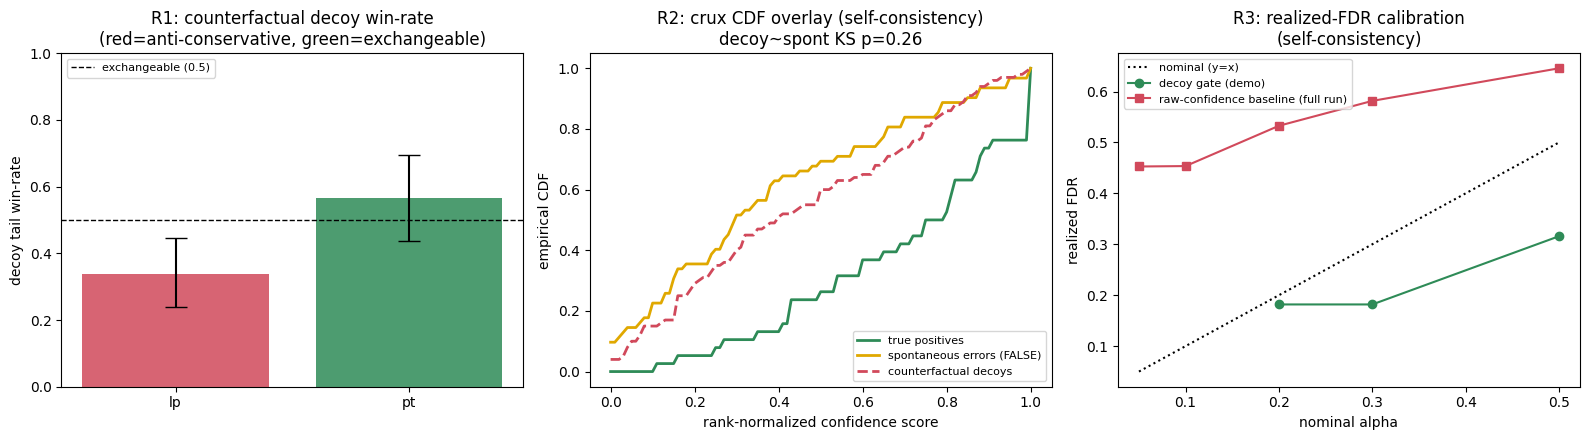


Headline reproduced: CALIBRATED(exchangeable) under the portable_full elicitation.


In [11]:
# ---- Text summary table: demo-recomputed vs full-run reported win-rates ----
print("Counterfactual decoy tail win-rate  (want ~0.5 = exchangeable)")
print(f"{'elicitation':<28}{'demo win-rate (95% CI)':<30}{'full-run reported':<20}")
ec = ref["elicitation_comparison"]
for tag, name in ELICITATIONS.items():
    cf = s1[tag]["counterfactual"]
    full = ec[view_for[tag]]["counterfactual_tail_win_rate"]
    demo = f"{cf['win_rate']:.3f} [{cf['ci'][0]:.3f}, {cf['ci'][1]:.3f}]"
    print(f"{name:<28}{demo:<30}{full:.3f}")

# ---- Plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: counterfactual win-rate by elicitation, with bootstrap CIs
ax = axes[0]
tags = list(ELICITATIONS)
wr = [s1[t]["counterfactual"]["win_rate"] for t in tags]
lo = [s1[t]["counterfactual"]["win_rate"] - s1[t]["counterfactual"]["ci"][0] for t in tags]
hi = [s1[t]["counterfactual"]["ci"][1] - s1[t]["counterfactual"]["win_rate"] for t in tags]
colors = ["#d1495b" if not (s1[t]["counterfactual"]["ci"][0] <= 0.5 <= s1[t]["counterfactual"]["ci"][1])
          else "#2e8b57" for t in tags]
ax.bar(tags, wr, yerr=[lo, hi], capsize=8, color=colors, alpha=0.85)
ax.axhline(0.5, ls="--", c="k", lw=1, label="exchangeable (0.5)")
ax.set_ylim(0, 1); ax.set_ylabel("decoy tail win-rate")
ax.set_title("R1: counterfactual decoy win-rate\n(red=anti-conservative, green=exchangeable)")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: crux CDF overlay (self-consistency 'pt')
ax = axes[1]
c = crux["pt"]["cdfs"]
ax.plot(c["x"], c["truepos"], label="true positives", c="#2e8b57", lw=2)
ax.plot(c["x"], c["spont"],   label="spontaneous errors (FALSE)", c="#e0a800", lw=2)
ax.plot(c["x"], c["decoy"],   label="counterfactual decoys", c="#d1495b", lw=2, ls="--")
ax.set_xlabel("rank-normalized confidence score"); ax.set_ylabel("empirical CDF")
ax.set_title(f"R2: crux CDF overlay (self-consistency)\n"
             f"decoy~spont KS p={crux['pt']['ks_decoy_vs_spont_p']:.2f}")
ax.legend(loc="lower right", fontsize=8)

# Panel 3: realized-FDR calibration (self-consistency gate vs full-run baseline)
ax = axes[2]
alphas = ALPHA_GRID
m_fdr = [r["realized_fdr"] if r["n_admitted"] > 0 else np.nan for r in gate["pt"]]
brows = {r["alpha"]: r for r in baseline_ref["portable_full"]["rows"]}
b_fdr = [brows[a]["baseline_realized_fdr"] if a in brows else np.nan for a in alphas]
ax.plot(alphas, alphas, ls=":", c="k", label="nominal (y=x)")
ax.plot(alphas, m_fdr, "o-", c="#2e8b57", label="decoy gate (demo)")
ax.plot(alphas, b_fdr, "s-", c="#d1495b", label="raw-confidence baseline (full run)")
ax.set_xlabel("nominal alpha"); ax.set_ylabel("realized FDR")
ax.set_title("R3: realized-FDR calibration\n(self-consistency)")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("demo_results.png", dpi=110, bbox_inches="tight")
plt.show()
print("\nHeadline reproduced:", ref["headline_verdict"],
      "under the", ref["headline_elicitation"], "elicitation.")